### **REINFORCE LUNAR LANDER KERAS using FIT**

REINFORCE is an on-policy, Monte Carlo policy-gradient algorithm. It directly optimizes the parameters of a **stochastic** policy. Instead of learning a value function (like Q-learning), REINFORCE updates the policy network to make actions that led to high returns more likely.
It stubbornly learns to hover, so that we add a penalty of -100 if truncated This solves the problem. 

**LunarLander vs CartPole — what changes:**

- **State**: 8-dim continuous vector (position, velocity, angle, angular velocity, two leg-contact flags) instead of CartPole's 4-dim.
- **Actions**: 4 discrete actions (0 = do nothing, 1 = fire left engine, 2 = fire main engine, 3 = fire right engine) instead of CartPole's 2.
- **Reward is already well-shaped** by the environment: positive for moving toward the pad, big bonus for landing, big penalty for crashing. **We do NOT need the `-100 on early termination` trick from the CartPole template** — the LunarLander reward already encodes failure correctly.
- **Solved threshold**: official benchmark is mean reward ≥ **200** over the last 100 episodes.
- **Harder**: expect a few hundred to a few thousand episodes with plain REINFORCE. CartPole solves in ~200.

In [1]:
import sys
import os
import time
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from PIL import Image

from keras.layers import Dense, Input
from keras.models import Sequential
from keras.optimizers import Adam

import tensorflow as tf
tf.keras.backend.set_floatx('float32')

# Silence TF warnings (optional)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
sys.stderr = open('err.txt', 'w')

2026-05-22 09:20:41.466354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 09:20:41.500013: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jaumemanero/RL/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_c

In [2]:
from tensorflow.python.client import device_lib
devices = device_lib.list_local_devices()
gpu_devices = [d for d in devices if d.device_type == 'GPU']
if gpu_devices:
    for gpu in gpu_devices:
        print('Using', gpu.physical_device_desc)
else:
    print('No GPU detected — training on CPU. Should still fit in a session.')

No GPU detected — training on CPU. Should still fit in a session.


#### **Hyperparameters**

LunarLander is significantly harder than CartPole, so a few values change:
- `EPISODES` budget is larger (~5000 instead of 2000)
- `solved_threshold` is 200 (the official LunarLander benchmark)
- Network is wider (64 → 64) — CartPole's 48 → 48 is too narrow for this state space
- Learning rate is tuned for the wider, deeper objective surface

In [3]:
EPISODES = 5_000
learning_rate = 5e-4
ROLLING_WINDOW = 100         # the official benchmark averages over 100 episodes, we use 40 to reduce training time (aligned with other examples)
solved_threshold = 200       # LunarLander is solved at mean(last 100) >= 200
MAX_EPISODES = EPISODES
MAX_STEPS_PER_EPISODE = 1500  # LunarLander  truncation we want to avoid hoovering pattern
EPS_TRAIN = 1                # We train only after EPS_TRAIN episodes in this way we reduce variance slightly
TRUNCATION_PENALTY = True

#### **REINFORCE Agent**

- `build_model` — a 2-hidden-layer MLP with softmax output
- `get_action` — sample an action from the softmax
- `discount_rewards` — Monte Carlo returns with discount γ
- `train_model` — REINFORCE update via the `sparse_categorical_crossentropy + sample_weight` trick

**The training trick.** For the action taken `a`, sparse categorical crossentropy is `−log π(a|s)`. Setting `sample_weight = advantage` weights the loss by the (normalized) return, so minimizing the loss maximizes `advantage · log π(a|s)` — exactly the REINFORCE objective.

**One speed fix vs the template.** The CartPole template calls `self.model.predict(state, batch_size=1)` once per environment step. In Keras `predict()` has heavy per-call overhead (it sets up a `tf.data` iterator), which makes a per-step loop very slow. We use `model(state, training=False)` instead — direct call, no overhead. For LunarLander this is the difference between ~5 min and ~25 min of training.

In [4]:
class RunningMeanStd:
    def __init__(self, shape, epsilon=1e-4):
        self.mean = np.zeros(shape, dtype=np.float32)
        self.var = np.ones(shape, dtype=np.float32)
        self.count = epsilon

    def update(self, x):
        x = np.asarray(x, dtype=np.float32).reshape(-1, *self.mean.shape)
        batch_mean = x.mean(axis=0)
        batch_var = x.var(axis=0)
        batch_count = x.shape[0]
        self._update_from_moments(batch_mean, batch_var, batch_count)

    def _update_from_moments(self, batch_mean, batch_var, batch_count):
        delta = batch_mean - self.mean
        total_count = self.count + batch_count

        new_mean = self.mean + delta * batch_count / total_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        m_2 = m_a + m_b + np.square(delta) * self.count * batch_count / total_count

        self.mean = new_mean.astype(np.float32)
        self.var = (m_2 / total_count).astype(np.float32)
        self.count = total_count

    def normalize(self, x):
        x = np.asarray(x, dtype=np.float32)
        return ((x - self.mean) / np.sqrt(self.var + 1e-8)).astype(np.float32)


class REINFORCEAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        # Hyperparameters
        self.discount_factor = 0.99   # higher than CartPole's 0.98; longer credit-assignment horizon
        self.learning_rate = learning_rate
        self.hidden1, self.hidden2 = 64, 64

        # Policy network
        self.model = self.build_model()

        # Per-episode buffers
        self.states, self.actions, self.rewards = [], [], []

    def build_model(self):
        opt = Adam(learning_rate=self.learning_rate,
                   beta_1=0.9, beta_2=0.999, epsilon=1e-08,
                   amsgrad=True, clipnorm=1.0)

        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(self.hidden1, activation='relu', dtype='float32'),
            Dense(self.hidden2, activation='relu', dtype='float32'),
            Dense(self.action_size, activation='softmax', dtype='float32'),
        ])
        model.summary()

        # Sparse CCE + sample_weight implements REINFORCE — see explanation above.
        model.compile(loss='sparse_categorical_crossentropy', optimizer=opt)
        return model

    # tf.function-wrapped forward pass — much faster than .predict() in a hot loop
    @tf.function(reduce_retracing=True)
    def _policy_probs(self, state):
        return self.model(state, training=False)

    def get_action(self, state):
        policy = self._policy_probs(state).numpy().flatten()
        # Numerical safety net — softmax can't actually produce zeros, but rounding can
        policy = np.clip(policy, 1e-8, 1.0)
        policy = policy / policy.sum()
        action = int(np.random.choice(self.action_size, p=policy))
        return action

    def discount_rewards(self, rewards):
        """Monte Carlo returns: G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ..."""
        discounted = np.zeros_like(rewards, dtype=np.float32)
        running = 0.0
        for t in reversed(range(len(rewards))):
            running = running * self.discount_factor + rewards[t]
            discounted[t] = running
        return discounted

    def append_sample(self, state, action, reward):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)

    def train_model(self):
        """REINFORCE update via sparse CCE + sample_weight = advantage."""
        if len(self.states) == 0:
            return

        # Compute returns and normalize to act as a baseline-subtracted advantage.
        # This is variance reduction — equivalent in expectation but trains much faster.
        returns = self.discount_rewards(np.array(self.rewards, dtype=np.float32))
        returns -= returns.mean()
        if returns.std() > 1e-8:
            returns /= returns.std()

        states = np.array(self.states, dtype=np.float32).squeeze(axis=1)
        actions = np.array(self.actions, dtype=np.int32)
        sample_weights = returns.astype(np.float32)

        # One gradient step on the whole episode
        self.model.fit(states, actions,
                       sample_weight=sample_weights,
                       epochs=1, verbose=0,
                       batch_size=len(states))

        # Reset buffers for next episode
        self.states, self.actions, self.rewards = [], [], []

#### **Training loop**

One major difference from the CartPole template: we **do not** rewrite the reward signal. CartPole's reward is a flat `+1` per step regardless of how the episode ended, so people add `-100` on early termination as a crude failure signal. LunarLander's built-in reward is much richer (negative for crashing, large positive for landing), so the same hack would just inject noise.

In [6]:
start_time = time.time()

env = gym.make('LunarLander-v3')
state_size = env.observation_space.shape[0]
# IMPORTANT: cast to int. env.action_space.n is np.int64, which Keras 3's Dense rejects.
action_size = int(env.action_space.n)

agent = REINFORCEAgent(state_size, action_size)
state_normalizer = RunningMeanStd(shape=(state_size,))

scores, episodes, rolling_avg_rewards = [], [], []

batch_states, batch_actions, batch_returns = [], [], []

for e in range(MAX_EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size]).astype(np.float32)
    score = 0.0
    step = 0
    done = False

    # Collect ONE episode's transitions in temporary lists

    ep_states, ep_actions, ep_rewards = [], [], []

    while not done:
        step += 1
        state_normalizer.update(state)
        normalized_state = state_normalizer.normalize(state)
        action = agent.get_action(normalized_state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size]).astype(np.float32)

        ep_states.append(normalized_state)
        ep_actions.append(action)
        ep_rewards.append(reward)

        score += reward
        state = next_state
        done = terminated or truncated or (step >= MAX_STEPS_PER_EPISODE)
        if truncated:
            if TRUNCATION_PENALTY:
               reward = -100

    # Compute returns for THIS episode and stash in the batch buffers.
    # Critical: do the discounting per-episode so the last step of each
    # episode has the correct (zero-future) bootstrap.
    ep_returns = agent.discount_rewards(np.array(ep_rewards, dtype=np.float32))
    batch_states.extend(ep_states)
    batch_actions.extend(ep_actions)
    batch_returns.extend(ep_returns)

    scores.append(score)
    rolling_avg = np.mean(scores[-ROLLING_WINDOW:])
    rolling_avg_rewards.append(rolling_avg)

    print(f"Episode: {e+1:4d}/{MAX_EPISODES}  Reward: {score:+8.2f}  "
          f"Rolling{ROLLING_WINDOW}: {rolling_avg:+8.2f}  Steps: {step:4d}  "
          f"len: {len(batch_states):4d} Terminated:{terminated}")

    # Every BATCH_EPISODES, do one gradient update with everything we have
    if (e + 1) % EPS_TRAIN == 0:
        states  = np.array(batch_states,  dtype=np.float32).squeeze(axis=1)
        actions = np.array(batch_actions, dtype=np.int32)
        returns = np.array(batch_returns, dtype=np.float32)

        # Normalize across the whole batch — this is the variance reduction.
        # Normalizing across many episodes is much more meaningful than
        # normalizing within one episode.
        returns -= returns.mean()
        if returns.std() > 1e-8:
            returns /= returns.std()

        agent.model.fit(states, actions,
                        sample_weight=returns,
                        epochs=1, verbose=0,
                        batch_size=len(states))

        # Reset batch buffers
        batch_states, batch_actions, batch_returns = [], [], []

    if len(scores) >= ROLLING_WINDOW and rolling_avg >= solved_threshold:
        print(f"\nSolved at episode {e+1}! Rolling{ROLLING_WINDOW} = {rolling_avg:.2f}")
        break

env.close()
elapsed_min = (time.time() - start_time) / 60
print(f"\nTraining completed in {elapsed_min:.2f} minutes")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,996 (19.52 KB)

 Trainable params: 4,996 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

Episode:    1/5000  Reward:  -259.83  Rolling100:  -259.83  Steps:  106  len:  106 Terminated:True
Episode:    2/5000  Reward:  -191.52  Rolling100:  -225.67  Steps:   95  len:   95 Terminated:True
Episode:    3/5000  Reward:   -65.61  Rolling100:  -172.32  Steps:   65  len:   65 Terminated:True
Episode:    4/5000  Reward:  -404.80  Rolling100:  -230.44  Steps:   86  len:   86 Terminated:True
Episode:    5/5000  Reward:   -86.45  Rolling100:  -201.64  Steps:  134  len:  134 Terminated:True
Episode:    6/5000  Reward:  -328.08  Rolling100:  -222.71  Steps:   94  len:   94 Terminated:True
Episode:    7/5000  Reward:  -200.71  Rolling100:  -219.57  Steps:   96  len:   96 Terminated:True
Episode:    8/5000  Reward:  -417.66  Rolling100:  -244.33  Steps:  131  len:  131 Terminated:True
Episode:    9/5000  Reward:  -129.16  Rolling100:  -231.53  Steps:  104  len:  104 Terminated:True
Episode:   10/5000  Reward:  -336.90  Rolling100:  -242.07  Steps:   80  len:   80 Terminated:True
Episode:  

#### **Training curve visualization**

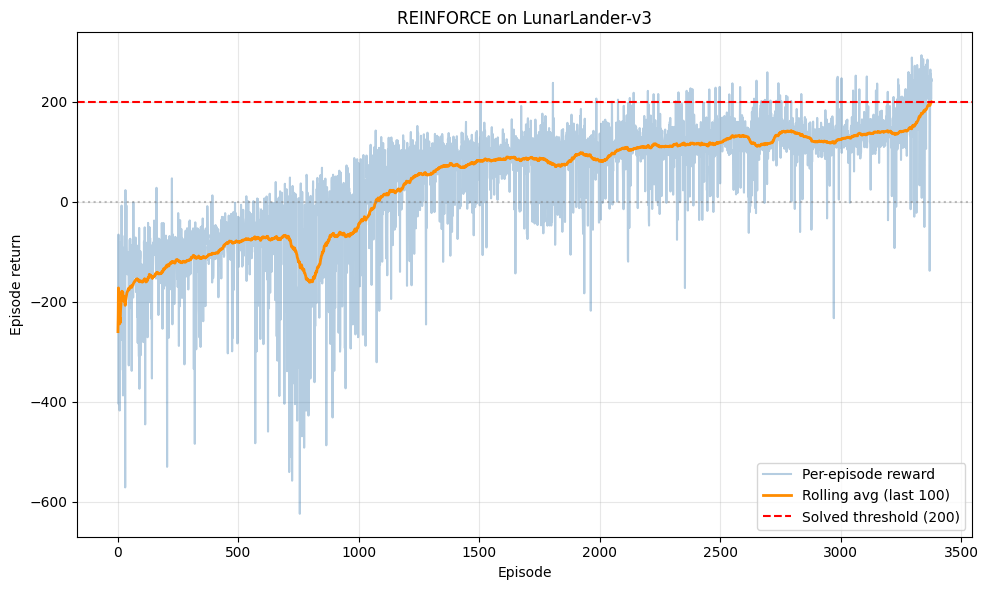

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(scores, color='steelblue', alpha=0.4, label='Per-episode reward')
plt.plot(rolling_avg_rewards, color='darkorange', linewidth=2,
         label=f'Rolling avg (last {ROLLING_WINDOW})')
plt.axhline(y=solved_threshold, color='red', linestyle='--',
            label=f'Solved threshold ({solved_threshold})')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.title('REINFORCE on LunarLander-v3')
plt.xlabel('Episode')
plt.ylabel('Episode return')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Evaluation Run 10 episodes**

Run 10 test episodes using the trained policy. We still sample actions (the policy is stochastic by design), but you could also take `argmax` over the softmax for a fully deterministic eval — usually a small win on LunarLander.

In [8]:
env = gym.make('LunarLander-v3')
test_rewards = []

for e_test in range(10):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size]).astype(np.float32)
    total_reward = 0.0
    for step in range(MAX_STEPS_PER_EPISODE):
        normalized_state = state_normalizer.normalize(state)
        action = agent.get_action(normalized_state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size]).astype(np.float32)
        total_reward += reward
        state = next_state
        if terminated or truncated:
            break
    test_rewards.append(total_reward)
    print(f"Test episode {e_test+1:2d}/10  Reward: {total_reward:+8.2f}  Steps: {step+1}")

env.close()
print(f"\nMean test reward: {np.mean(test_rewards):+.2f}  (std {np.std(test_rewards):.2f})")

Test episode  1/10  Reward:  +284.02  Steps: 367
Test episode  2/10  Reward:  +248.87  Steps: 425
Test episode  3/10  Reward:   -38.46  Steps: 308
Test episode  4/10  Reward:  +224.47  Steps: 339
Test episode  5/10  Reward:  +280.42  Steps: 365
Test episode  6/10  Reward:   +98.75  Steps: 1000
Test episode  7/10  Reward:   +28.26  Steps: 280
Test episode  8/10  Reward:  +253.39  Steps: 383
Test episode  9/10  Reward:  +256.93  Steps: 324
Test episode 10/10  Reward:  +252.02  Steps: 365

Mean test reward: +188.87  (std 109.86)


#### **Render an episode as a GIF**

In [9]:
env = gym.make('LunarLander-v3', render_mode='rgb_array')
frames = []

state, _ = env.reset()
state = np.reshape(state, [1, state_size]).astype(np.float32)
tot_rewards = 0.0

for step in range(MAX_STEPS_PER_EPISODE):
    normalized_state = state_normalizer.normalize(state)
    action = agent.get_action(normalized_state)
    next_state, reward, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    next_state = np.reshape(next_state, [1, state_size]).astype(np.float32)
    tot_rewards += reward
    state = next_state
    
    if terminated or truncated:
        print(f"Episode reward: {tot_rewards:+.2f}  Steps: {step+1}")
        break

env.close()

def save_frames_as_gif(frames, path='./', filename='LUNARLANDER_REINFORCE_FIT.gif'):
    images = [Image.fromarray(f) for f in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:],
                   duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")

save_frames_as_gif(frames)
print('total reward', tot_rewards)

Episode reward: +207.20  Steps: 337
Saved GIF to: ./LUNARLANDER_REINFORCE_FIT.gif
total reward 207.2033659852488


#### **Notes on this implementation & next steps**

**Why plain REINFORCE struggles on LunarLander.** Variance. The Monte Carlo return is an unbiased gradient estimator but a very noisy one. Each episode gives you one trajectory's worth of signal, and LunarLander trajectories are long (often 200+ steps) and reward-sparse compared to CartPole. You'll see the rolling average crawl upward, but with big swings.

**Things to try if you want to improve it:**
- **Add a critic** → this becomes Advantage Actor-Critic (A2C). Much lower variance.
- **Update over multiple episodes instead of one** → bigger batches, less noisy gradients.
- **Use entropy regularization** → add `-β · H(π)` to the loss to keep the policy exploring early on.
- **Switch to PPO** → clipped surrogate objective, multiple epochs per batch, much sample-efficient.

# import session_info
session_info.show(html=False)